# Lopputyö
- Joonas Harjula
- 
## K nearest neighbour assignment - Part A

Using included autos dataset (autos-clean.csv) predict the city-mpg of gas powered cars. Following features should be used in prediction:
- engine-size
- horsepower
- curb-weight
- length
- highway-mpg

Prediction algorithm in this case should be kNN with k value of 5. 
Use train_test_split function with test_size=0.3 and random_state=100.

Evaluate the prediction model by calculating values of R-squared, MAE, MSE and RMSE. 
Draw a scatter plot from test set prediction and true values.


### Step 1: import all needed libraries

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn import preprocessing
from sklearn import metrics
import math



### Step 2: read data and fill NaN values with suitable method

In [10]:
df = pd.read_csv("data/autos.clean.csv")
print(df[0:5])
print(df.describe())
print()
for column in df:
    print(f"amount of NaNs in {column}: {df[column].isna().sum()}")
    print(df[column].isna())

   symboling  normalized-losses         make fuel-type aspiration  \
0          3                122  alfa-romero       gas        std   
1          3                122  alfa-romero       gas        std   
2          1                122  alfa-romero       gas        std   
3          2                164         audi       gas        std   
4          2                164         audi       gas        std   

  num-of-doors   body-style drive-wheels engine-location  wheel-base  ...  \
0          two  convertible          rwd           front        88.6  ...   
1          two  convertible          rwd           front        88.6  ...   
2          two    hatchback          rwd           front        94.5  ...   
3         four        sedan          fwd           front        99.8  ...   
4         four        sedan          4wd           front        99.4  ...   

   engine-size  fuel-system  bore  stroke compression-ratio horsepower  \
0          130         mpfi  3.47    2.68       

### Step 3: Select suitable columns for analysis

In [11]:
print(df.columns)
selected_columns = [
    "engine-size", 
    "horsepower", 
    "curb-weight",
    "length",
    "highway-mpg",
    "city-mpg"]
df2 = df[selected_columns]
df2.describe()

Index(['symboling', 'normalized-losses', 'make', 'fuel-type', 'aspiration',
       'num-of-doors', 'body-style', 'drive-wheels', 'engine-location',
       'wheel-base', 'length', 'width', 'height', 'curb-weight', 'engine-type',
       'num-of-cylinders', 'engine-size', 'fuel-system', 'bore', 'stroke',
       'compression-ratio', 'horsepower', 'peak-rpm', 'city-mpg',
       'highway-mpg', 'price'],
      dtype='object')


,engine-size,horsepower,curb-weight,length,highway-mpg,city-mpg
count,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000
mean,126.875622,103.405534,2555.666667,174.200995,30.686567,25.179104
std,41.546834,37.365700,517.296727,12.322175,6.815150,6.423220
min,61.000000,48.000000,1488.000000,141.100000,16.000000,13.000000
25%,98.000000,70.000000,2169.000000,166.800000,25.000000,19.000000
50%,120.000000,95.000000,2414.000000,173.200000,30.000000,24.000000
75%,141.000000,116.000000,2926.000000,183.500000,34.000000,30.000000
max,326.000000,262.000000,4066.000000,208.100000,54.000000,49.000000


### Step 4: Split data into training and test data sets

In [12]:
X = df2.iloc[:, :-1]
y = df2.iloc[:, -1]
print(X.describe())
print()
print(y.describe())

# X is the predictor variables, y is what we try to predict
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=100)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

       engine-size  horsepower  curb-weight      length  highway-mpg
count   201.000000  201.000000   201.000000  201.000000   201.000000
mean    126.875622  103.405534  2555.666667  174.200995    30.686567
std      41.546834   37.365700   517.296727   12.322175     6.815150
min      61.000000   48.000000  1488.000000  141.100000    16.000000
25%      98.000000   70.000000  2169.000000  166.800000    25.000000
50%     120.000000   95.000000  2414.000000  173.200000    30.000000
75%     141.000000  116.000000  2926.000000  183.500000    34.000000
max     326.000000  262.000000  4066.000000  208.100000    54.000000

count    201.000000
mean      25.179104
std        6.423220
min       13.000000
25%       19.000000
50%       24.000000
75%       30.000000
max       49.000000
Name: city-mpg, dtype: float64
(140, 5)
(61, 5)
(140,)
(61,)


### Step 5: Scale the predictors of data

In [14]:
print(X_train[0:3]); print()

scaler = preprocessing.StandardScaler()
use_scaler = True
if use_scaler:
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.fit_transform(X_test)

print(X_train[0:3])

[[-0.6797591   0.30157926 -0.4966104  -0.46394175 -0.23774733]
 [-0.82703732 -0.9570442  -1.06422775 -1.35928761  1.11162941]
 [-0.40974904  0.01552847 -0.42565823  0.15651723 -0.08781658]]

[[-0.6797591   0.30157926 -0.4966104  -0.46394175 -0.23774733]
 [-0.82703732 -0.9570442  -1.06422775 -1.35928761  1.11162941]
 [-0.40974904  0.01552847 -0.42565823  0.15651723 -0.08781658]]


### Step 6: "Train" the K-nearest neighbour model with 5 neighbours

Neighbours mean that algorithm looks that amount of closest data points. E.g if closest 5 contain 1x banana 2x orange 1x apple 1x grape, then it is closest to orange...

Distance has many options. But I will use the most normal one called Euclidean distance, which is "bird road" distance. Manhattan would meanwhile consider both x and y lengths for the distance a bit like driwing with car in a city.

Because K nearest neighbour model stores all datapoints into memory, it doesn't exactly learn like some other machine learning models. One of its strengths is its simplicity.

In [15]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

KNeighborsClassifier()

### Step 7: See how well trained model predicts based on test data


In [17]:
y_predict = knn.predict(X_test)
print(y_predict)
print(f"Accuracy: {metrics.accuracy_score(y_test, y_predict)}")

[23 26 27 19 28 17 24 19 31 14 31 25 31 22 26 31 26 31 23 19 26 23 19 24
 31 16 19 27 31 21 26 19 27 31 24 38 26 27 30 19 24 19 19 31 28 26 19 17
 31 19 38 31 23 31 24 22 24 19 19 27 16]
Accuracy: 0.5409836065573771


### Step 8: Draw a scatter plot from test predictions and true values

Note: Will use y_test as x-axis and see how well y_test explains y_predict

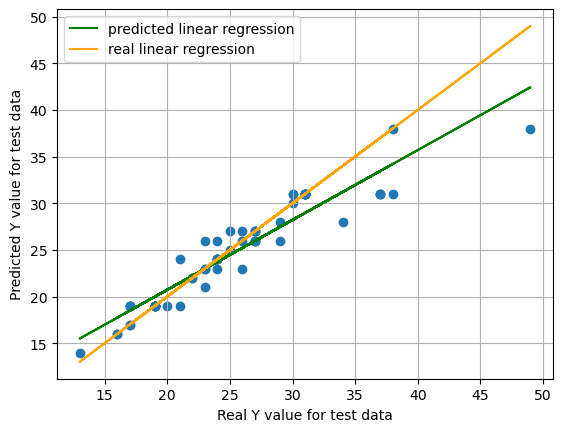

In [18]:
plt.scatter(y_test, y_predict)
plt.grid()
plt.xlabel("Real Y value for test data")
plt.ylabel("Predicted Y value for test data")


# add super simple linear regression line
m, b = np.polyfit(y_test, y_predict, 1)
plt.plot(y_test, m*y_test+b, color="green", label="predicted linear regression")
plt.plot(y_test, y_test, color="orange", label="real linear regression")
plt.legend()
plt.show()

### Step 9: Calculate R-squared, MAE, MSE and RMSE
IMPORTANT: These require the predicted variable to be numerical

R-squared value tells how many points fall on the regression line.

Mean absolute error (MAE) value tells only what is the cumulative absolute error.
MAE does not give weights to outliers, so it is good only if outliers don't matter.
Uses absolute values (e.g -5 = 5) to determine cumulative error.

Mean square error (MSE) value does not use absolute values like MAE, 
but it squares all errors. 
Therefore, outliers become much heavier weight. E.g -5 would be 25,
but -10 would be 100. It is useful when outliers are unacceptable.

Root mean square error (RMSE) is basically same as MSE, but the value is
scaled back to original scale by squarerooting the cumulative sum of all errors.
Personally i think RMSE should be always used rather than MSE.
RMSE also has similar benefit that outliers are unacceptable.

In [19]:
r2_test_score = metrics.r2_score(y_test, y_predict)
print(f"R Squared Test Score: {r2_test_score:.2f}")

mae = metrics.mean_absolute_error(y_test, y_predict)
print(f"Mean Absolute Error: {mae:.2f}")

mse = metrics.mean_squared_error(y_test, y_predict)
print(f"Mean squared error: {mse:.2f}")

rmse = metrics.root_mean_squared_error(y_test, y_predict)
print(f"Root Mean Squared Error: {rmse:.2f}")
print(f"Root Mean Squared Error (alternative way): {math.sqrt(mse):.2f}")

R Squared Test Score: 0.86
Mean Absolute Error: 1.31
Mean squared error: 6.43
Root Mean Squared Error: 2.54
Root Mean Squared Error (alternative way): 2.54


### Summary Part A:
As can be seen from the scatter plot, the model predicts quite well the city miles per gallon.
On low values giving too high, and on high values too low estimate.

On the other hand, the accuracy of model is only 0.54, which could be thought to be alarmingly low.
But, because the data we have is numerical, accuracy tends to get lower, and 0.54 can be quite good,
considering the model predicts from several dozens of integner umbers a correct one over 50% of time.

This view is also supported from the relatively high R2 score of 0.86, 
which means that the model explains about 86% of the data's variance.

The MAE value is very low, RMSE value is twice higher but still only moderate at 2.5, 
meaning, there are probably some outliers (especially on lowest and highest values),
and lots of small mistakes, where number should be e.g 30 but is 31.

Therefore, overall the model is quite good despite its lowish accuracy.

# K nearest neighbour assignment - Part B

Using included autos dataset (autos-clean.csv) predict feature drive-wheels
using features: 'engine-size', 'curb-weight'

Evaluate the predicted model using accuracy of the test_set.
Visualize the results using confusion matrix.

### Step 1: Import all needed libraries

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn import preprocessing
from sklearn import metrics
import seaborn as sns
import math

### Step 2: Read data and fill NaN values with suitable method

In [21]:
df = pd.read_csv("data/autos.clean.csv")
print(df[0:5])
print(df.describe())
print()
for column in df:
    print(f"amount of NaNs in {column}: {df[column].isna().sum()}")
    print(df[column].isna())

   symboling  normalized-losses         make fuel-type aspiration  \
0          3                122  alfa-romero       gas        std   
1          3                122  alfa-romero       gas        std   
2          1                122  alfa-romero       gas        std   
3          2                164         audi       gas        std   
4          2                164         audi       gas        std   

  num-of-doors   body-style drive-wheels engine-location  wheel-base  ...  \
0          two  convertible          rwd           front        88.6  ...   
1          two  convertible          rwd           front        88.6  ...   
2          two    hatchback          rwd           front        94.5  ...   
3         four        sedan          fwd           front        99.8  ...   
4         four        sedan          4wd           front        99.4  ...   

   engine-size  fuel-system  bore  stroke compression-ratio horsepower  \
0          130         mpfi  3.47    2.68       

### Step 3: Select suitable columns for analysis

In [22]:
print(df["drive-wheels"].unique())
selected_columns = [
    "engine-size", 
    "curb-weight",
    "drive-wheels"]
df2 = df[selected_columns]
df2.describe()
df2[0:5]

['rwd' 'fwd' '4wd']


,engine-size,curb-weight,drive-wheels
0,130,2548,rwd
1,130,2548,rwd
2,152,2823,rwd
3,109,2337,fwd
4,136,2824,4wd


### Step 4: Split data into training and test data sets

Note that we must use the parameter "stratify=y", 
because some tire types are so rare.

In [23]:
X = df2.iloc[:, :-1]
y = df2.iloc[:, -1]
print(X.describe())
print()
print(y.describe())

# X is the predictor variables, y is what we try to predict
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

       engine-size  curb-weight
count   201.000000   201.000000
mean    126.875622  2555.666667
std      41.546834   517.296727
min      61.000000  1488.000000
25%      98.000000  2169.000000
50%     120.000000  2414.000000
75%     141.000000  2926.000000
max     326.000000  4066.000000

count     201
unique      3
top       fwd
freq      118
Name: drive-wheels, dtype: object
(140, 2)
(61, 2)
(140,)
(61,)


### Step 5: Scale the predictors of data

In [24]:
print(X_train[0:3]); print()
print(X_train.max())

scaler = preprocessing.StandardScaler()
use_scaler = True
if use_scaler:
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.fit_transform(X_test)

print(X_train[0:3])
print(X_train.max())

     engine-size  curb-weight
78           122         2328
175          171         3016
135          108         2120

engine-size     326
curb-weight    4066
dtype: int64
[[-0.14279529 -0.43906012]
 [ 0.94804622  0.8790508 ]
 [-0.45446429 -0.83755877]]
4.398667319182249


### Step 6: "Train" the K-nearest neighbour model with 5 neighbours

Neighbours mean that algorithm looks that amount of closest data points. E.g if closest 5 contain 1x banana 2x orange 1x apple 1x grape, then it is closest to orange...

Distance has many options. But I will use the most normal one called Euclidean distance, which is "bird road" distance. Manhattan would meanwhile consider both x and y lengths for the distance a bit like driwing with car in a city.

Because K nearest neighbour model stores all datapoints into memory, it doesn't exactly learn like some other machine learning models. One of its strengths is its simplicity.

In [25]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

KNeighborsClassifier()

### Step 7: See how well trained model predicts based on test data
Evaluate the predicted model using accuracy of the test_set
In this case the predicted variable is string classes, 
so accurasy is expected to be much higher than in last example of city miles per gallon,
where predictions were numerical.

In [26]:
y_predict = knn.predict(X_test)
print(f"Accuracy: {metrics.accuracy_score(y_test, y_predict):.2f}")

Accuracy: 0.80


### Step 8: Visualize the results using confusion matrix

[[ 0  1  1]
 [ 0 31  5]
 [ 1  4 18]]


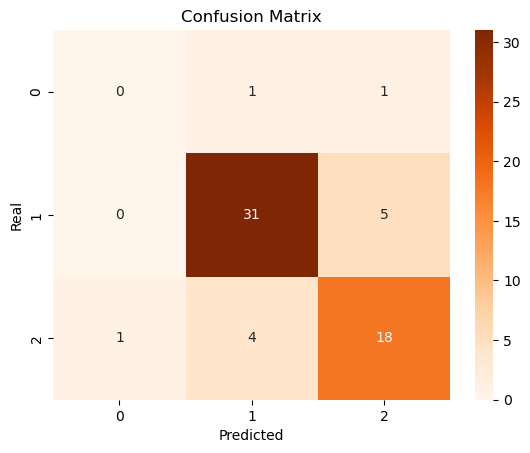

In [27]:
cm = metrics.confusion_matrix(y_test, y_predict)
print(cm)

# heatmap of confusion matrix
sns.heatmap(pd.DataFrame(cm), annot=True, cmap="Oranges")
plt.xlabel("Predicted")
plt.ylabel("Real")
plt.title("Confusion Matrix")
plt.show()

### Summary Part B: 
The accuracy of our model was switching between 0.65 and 0.87
depending how the data was split to test and training data.
We were trying to predict, which type our wheel is from next 3 types:
['rwd' 'fwd' '4wd']

The latest heatmap has one of the best fairing models, 
but it was unable to predict type 0 wheels correctly.

Personally, i think the amount of data might simply be lacking. 
There is plenty of data where wheel is type 1 or 2, but very few with type 0 wheel.
The model would probably at this point be more accurate, 
if we would not try to predict type 0 wheel at all.
But for this assignment, i chose to predict all types of wheels,
and I also used the stratified=y parameter in splitting data to training and test data sets.